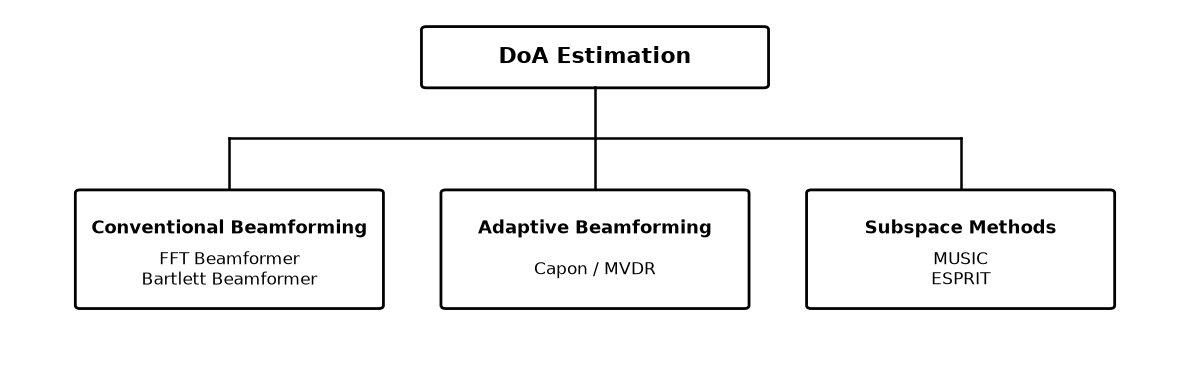

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

def add_box(ax, x, y, w, h, title, items=None, title_size=14, item_size=11):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.03,rounding_size=0.05",
        fill=False,
        linewidth=2
    )
    ax.add_patch(box)

    if items is None:
        ax.text(
            x + w / 2, y + h / 2,
            title,
            ha="center", va="center",
            fontsize=title_size, fontweight="bold"
        )
    else:
        # Bold category title
        ax.text(
            x + w / 2, y + h * 0.68,
            title,
            ha="center", va="center",
            fontsize=title_size, fontweight="bold"
        )

        # Algorithms listed below
        item_text = "\n".join(items)
        ax.text(
            x + w / 2, y + h * 0.32,
            item_text,
            ha="center", va="center",
            fontsize=item_size
        )

fig, ax = plt.subplots(figsize=(12, 4))
ax.set_ylim(2.2, 8)
ax.set_xlim(0, 12)
# ax.set_ylim(0, 8)
ax.axis("off")

# ------------------------------------------------------------
# Top block
# ------------------------------------------------------------
add_box(ax, 4.25, 6.81, 3.5, 0.9, "DoA Estimation", title_size=16)

# ------------------------------------------------------------
# Three subblocks
# ------------------------------------------------------------
add_box(
    ax, 0.7, 3.35, 3.1, 1.8,
    "Conventional Beamforming",
    items=["FFT Beamformer", "Bartlett Beamformer"],
    title_size=13, item_size=12
)

add_box(
    ax, 4.45, 3.35, 3.1, 1.8,
    "Adaptive Beamforming",
    items=["Capon / MVDR"],
    title_size=13, item_size=12
)

add_box(
    ax, 8.2, 3.35, 3.1, 1.8,
    "Subspace Methods",
    items=["MUSIC", "ESPRIT"],
    title_size=13, item_size=12
)

# ------------------------------------------------------------
# Connections
# ------------------------------------------------------------
ax.plot([6.0, 6.0], [6.8, 6.0], "k-", lw=1.8)     # vertical from top block
ax.plot([2.25, 9.75], [6.0, 6.0], "k-", lw=1.8)   # horizontal branch
ax.plot([2.25, 2.25], [6.0, 5.2], "k-", lw=1.8)   # left drop
ax.plot([6.0, 6.0], [6.0, 5.2], "k-", lw=1.8)     # middle drop
ax.plot([9.75, 9.75], [6.0, 5.2], "k-", lw=1.8)   # right drop

plt.tight_layout()
plt.show()

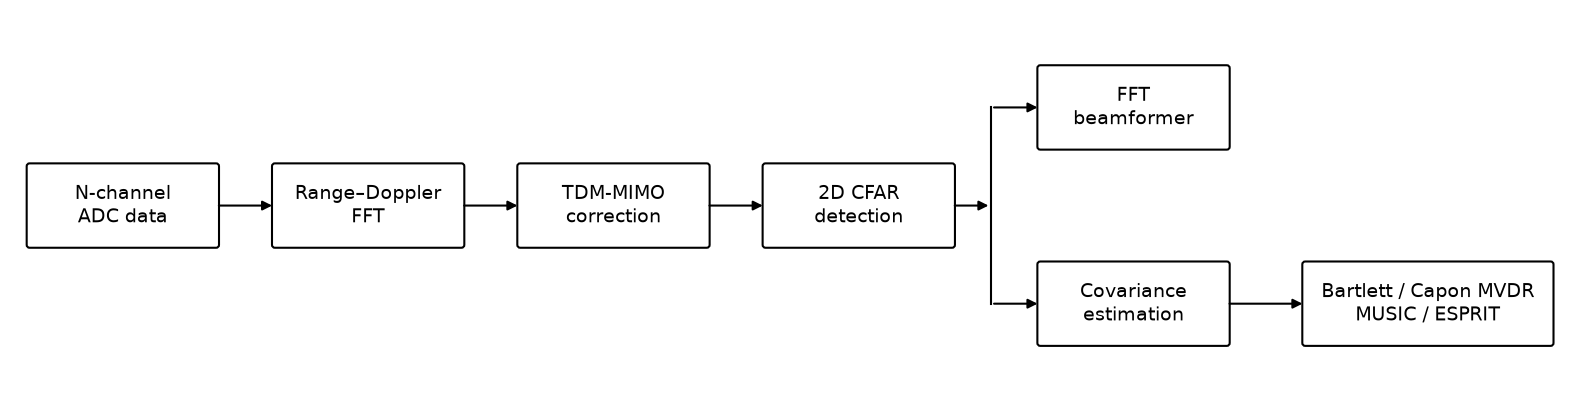

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


def add_block(ax, x, y, width, height, text, fontsize=14):
    block = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.03",
        linewidth=1.5,
        facecolor="white",
        edgecolor="black",
    )
    ax.add_patch(block)

    ax.text(
        x + width / 2,
        y + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
    )


def add_arrow(ax, start, end):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=1.5,
        color="black",
    )
    ax.add_patch(arrow)


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 4.5))

block_w = 1.9
block_h = 0.8

# Main FMCW processing chain
add_block(ax, 0.2, 1.8, block_w, block_h, "N-channel\nADC data")
add_block(ax, 2.7, 1.8, block_w, block_h, "Range–Doppler\nFFT")
add_block(ax, 5.2, 1.8, block_w, block_h, "TDM-MIMO\ncorrection")
add_block(ax, 7.7, 1.8, block_w, block_h, "2D CFAR\ndetection")

# DoA-processing branches
add_block(ax, 10.5, 2.8, block_w, block_h, "FFT\nbeamformer")
add_block(ax, 10.5, 0.8, block_w, block_h, "Covariance\nestimation")

add_block(
    ax,
    13.2,
    0.8,
    2.5,
    block_h,
    "Bartlett / Capon MVDR\nMUSIC / ESPRIT",
)

# Main-chain arrows
add_arrow(ax, (2.1, 2.2), (2.7, 2.2))
add_arrow(ax, (4.6, 2.2), (5.2, 2.2))
add_arrow(ax, (7.1, 2.2), (7.7, 2.2))

# Branch after CFAR detection
branch_x = 10.0

add_arrow(ax, (9.6, 2.2), (branch_x, 2.2))

ax.plot(
    [branch_x, branch_x],
    [1.2, 3.2],
    color="black",
    linewidth=1.5,
)

add_arrow(ax, (branch_x, 3.2), (10.5, 3.2))
add_arrow(ax, (branch_x, 1.2), (10.5, 1.2))

# Covariance-based DoA algorithms
add_arrow(ax, (12.4, 1.2), (13.2, 1.2))

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_xlim(0, 16)
ax.set_ylim(0.3, 4.2)
ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout()

plt.savefig(
    "../docs/images/fmcw_mimo_doa_processing_chain.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

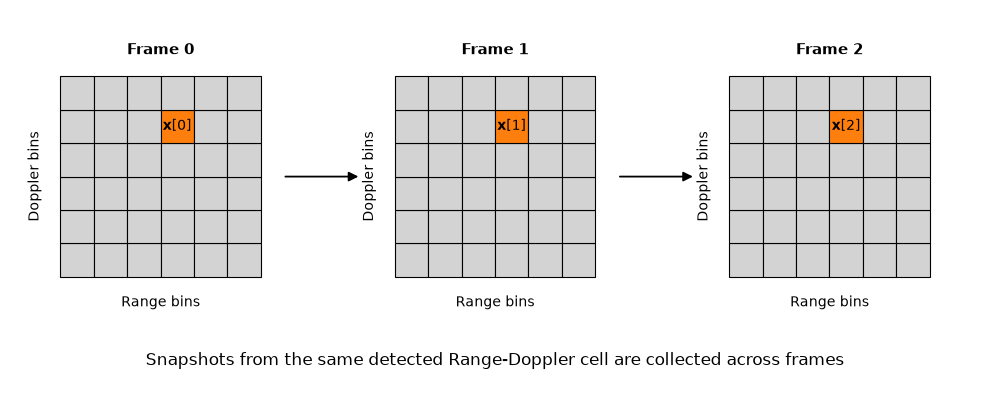

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
n_frames = 3
n_range_bins = 6
n_doppler_bins = 6

selected_range_bin = 3
selected_doppler_bin = 4

cell_size = 1.0
map_spacing = 4.0


# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------
def draw_rd_map(
    ax,
    x0,
    y0,
    n_range,
    n_doppler,
    selected_cell,
    frame_index,
):
    """Draw one simplified Range-Doppler map."""

    # Draw grid cells
    for doppler_bin in range(n_doppler):
        for range_bin in range(n_range):
            is_selected = (
                range_bin == selected_cell[0]
                and doppler_bin == selected_cell[1]
            )

            facecolor = "lightgray" if not is_selected else "tab:orange"

            cell = Rectangle(
                (
                    x0 + range_bin * cell_size,
                    y0 + doppler_bin * cell_size,
                ),
                cell_size,
                cell_size,
                facecolor=facecolor,
                edgecolor="black",
                linewidth=0.8,
            )
            ax.add_patch(cell)

    map_width = n_range * cell_size
    map_height = n_doppler * cell_size

    # Frame label
    ax.text(
        x0 + map_width / 2,
        y0 + map_height + 0.55,
        f"Frame {frame_index}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

    # Snapshot label
    selected_x = x0 + (selected_cell[0] + 0.5) * cell_size
    selected_y = y0 + (selected_cell[1] + 0.5) * cell_size

    ax.text(
        selected_x,
        selected_y,
        rf"$\mathbf{{x}}[{frame_index}]$",
        ha="center",
        va="center",
        fontsize=10,
    )

    # Axis labels
    ax.text(
        x0 + map_width / 2,
        y0 - 0.55,
        "Range bins",
        ha="center",
        va="top",
        fontsize=10,
    )

    ax.text(
        x0 - 0.55,
        y0 + map_height / 2,
        "Doppler bins",
        ha="right",
        va="center",
        rotation=90,
        fontsize=10,
    )


# ------------------------------------------------------------
# Draw figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

y0 = 1.0
map_width = n_range_bins * cell_size

for frame_index in range(n_frames):
    x0 = frame_index * (map_width + map_spacing)

    draw_rd_map(
        ax=ax,
        x0=x0,
        y0=y0,
        n_range=n_range_bins,
        n_doppler=n_doppler_bins,
        selected_cell=(selected_range_bin, selected_doppler_bin),
        frame_index=frame_index,
    )

    # Arrow between consecutive frames
    if frame_index < n_frames - 1:
        arrow_start = (
            x0 + map_width + 0.65,
            y0 + n_doppler_bins * cell_size / 2,
        )
        arrow_end = (
            x0 + map_width + map_spacing - 1.0,
            y0 + n_doppler_bins * cell_size / 2,
        )

        arrow = FancyArrowPatch(
            arrow_start,
            arrow_end,
            arrowstyle="-|>",
            mutation_scale=14,
            linewidth=1.3,
            color="black",
        )
        ax.add_patch(arrow)


# ------------------------------------------------------------
# Covariance-estimation annotation
# ------------------------------------------------------------
total_width = (
    n_frames * map_width
    + (n_frames - 1) * map_spacing
)

ax.text(
    total_width / 2,
    -1.5,
    r"Snapshots from the same detected Range-Doppler cell "
    r"are collected across frames",
    ha="center",
    va="center",
    fontsize=14,
)

ax.set_xlim(-1.5, total_width + 1.5)
ax.set_ylim(-2.5, y0 + n_doppler_bins * cell_size + 2.0)
ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout()

plt.savefig(
    "../docs/images/snapshot_per_frame.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

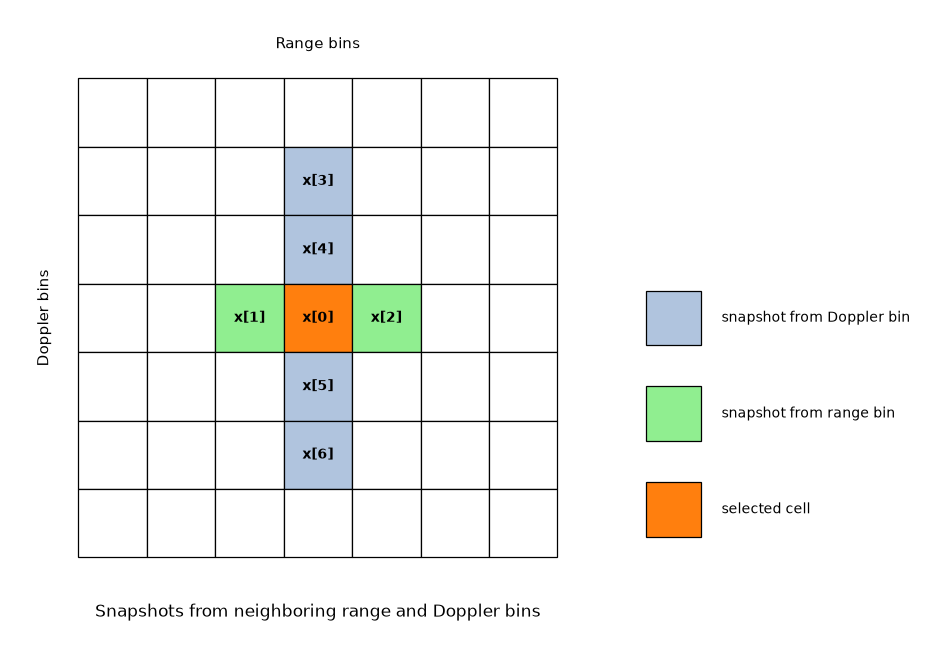

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
n_range_bins = 7
n_doppler_bins = 7
cell_size = 1.0

# Selected center cell
r0 = 3
d0 = 3

# Neighboring cells:
# Doppler: 2 cells on each side
# Range:   1 cell on each side
range_start, range_end = r0 - 1, r0 + 1
doppler_start, doppler_end = d0 - 2, d0 + 2

cut_color = "tab:orange"
range_snapshot_color = "lightgreen"
doppler_snapshot_color = "lightsteelblue"
bg_color = "white"


# ------------------------------------------------------------
# Build snapshot labels
# ------------------------------------------------------------
labels = {(r0, d0): "x[0]"}

idx = 1

# Neighboring range-bin snapshots
for r in range(range_start, range_end + 1):
    if r == r0:
        continue

    labels[(r, d0)] = f"x[{idx}]"
    idx += 1

# Neighboring Doppler-bin snapshots
for d in range(doppler_start, doppler_end + 1):
    if d == d0:
        continue

    labels[(r0, d)] = f"x[{idx}]"
    idx += 1


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6.8))

# Draw RD grid
for d in range(n_doppler_bins):
    for r in range(n_range_bins):

        is_selected_cell = (r, d) == (r0, d0)

        is_range_snapshot = (
            d == d0
            and range_start <= r <= range_end
            and r != r0
        )

        is_doppler_snapshot = (
            r == r0
            and doppler_start <= d <= doppler_end
            and d != d0
        )

        if is_selected_cell:
            facecolor = cut_color
        elif is_range_snapshot:
            facecolor = range_snapshot_color
        elif is_doppler_snapshot:
            facecolor = doppler_snapshot_color
        else:
            facecolor = bg_color

        rect = Rectangle(
            (r * cell_size, d * cell_size),
            cell_size,
            cell_size,
            facecolor=facecolor,
            edgecolor="black",
            linewidth=0.9,
        )
        ax.add_patch(rect)

        # Add labels to the selected and snapshot cells
        if (r, d) in labels:
            ax.text(
                r + 0.5,
                d + 0.5,
                labels[(r, d)],
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold",
            )


# ------------------------------------------------------------
# Range / Doppler labels
# ------------------------------------------------------------
ax.text(
    n_range_bins / 2,
    -0.5,
    "Range bins",
    ha="center",
    va="center",
    fontsize=11,
)

ax.text(
    n_range_bins / 2,
    n_doppler_bins + 0.8,
    "Snapshots from neighboring range and Doppler bins",
    ha="center",
    va="center",
    fontsize=12,
)

ax.text(
    -0.5,
    n_doppler_bins / 2,
    "Doppler bins",
    ha="center",
    va="center",
    rotation=90,
    fontsize=11,
)


# ------------------------------------------------------------
# Legend on the right
# ------------------------------------------------------------
legend_x = n_range_bins + 1.3
legend_y_top = 5.9
legend_box = 0.8
legend_gap = 1.4

legend_items = [
    (cut_color, "selected cell"),
    (range_snapshot_color, "snapshot from range bin"),
    (doppler_snapshot_color, "snapshot from Doppler bin"),
]

for index, (color, text) in enumerate(legend_items):
    legend_y = legend_y_top - index * legend_gap

    ax.add_patch(
        Rectangle(
            (legend_x, legend_y),
            legend_box,
            legend_box,
            facecolor=color,
            edgecolor="black",
            linewidth=0.9,
        )
    )

    ax.text(
        legend_x + 1.1,
        legend_y + legend_box / 2,
        text,
        va="center",
        fontsize=10,
    )


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_xlim(-1.0, n_range_bins + 5.5)
ax.set_ylim(-1.0, n_doppler_bins + 1.5)
ax.set_aspect("equal")
ax.invert_yaxis()
ax.axis("off")

plt.tight_layout()

plt.savefig(
    "../docs/images/range_doppler_neighboring_bins.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

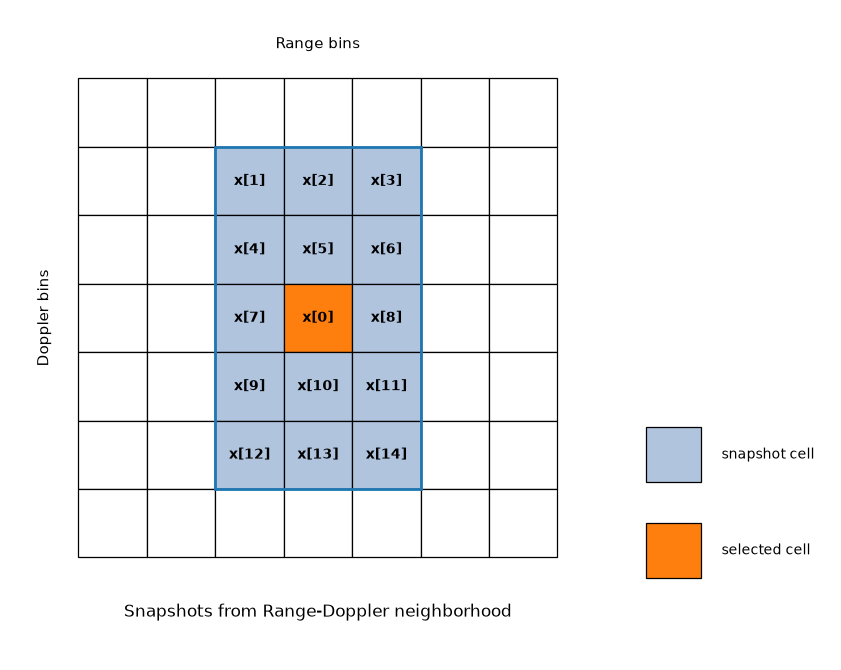

In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
n_range_bins = 7
n_doppler_bins = 7
cell_size = 1.0

# Selected center cell
r0 = 3
d0 = 3

# Snapshot neighborhood:
# Doppler: 2 cells on each side  -> d0-2 ... d0+2
# Range:   1 cell on each side   -> r0-1 ... r0+1
r_start, r_end = r0 - 1, r0 + 1
d_start, d_end = d0 - 2, d0 + 2

cut_color = "tab:orange"
snapshot_color = "lightsteelblue"
bg_color = "white"


# ------------------------------------------------------------
# Build snapshot labels
# ------------------------------------------------------------
labels = {(r0, d0): "x[0]"}  # selected cell

idx = 1
for d in range(d_start, d_end + 1):
    for r in range(r_start, r_end + 1):
        if (r, d) == (r0, d0):
            continue
        labels[(r, d)] = f"x[{idx}]"
        idx += 1


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6.8))

# Draw RD grid
for d in range(n_doppler_bins):
    for r in range(n_range_bins):

        in_snapshot_region = (r_start <= r <= r_end) and (d_start <= d <= d_end)

        if (r, d) == (r0, d0):
            facecolor = cut_color
        elif in_snapshot_region:
            facecolor = snapshot_color
        else:
            facecolor = bg_color

        rect = Rectangle(
            (r * cell_size, d * cell_size),
            cell_size,
            cell_size,
            facecolor=facecolor,
            edgecolor="black",
            linewidth=0.9,
        )
        ax.add_patch(rect)

        # Add labels to selected and snapshot cells
        if (r, d) in labels:
            ax.text(
                r + 0.5,
                d + 0.5,
                labels[(r, d)],
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold",
            )

# Outline snapshot neighborhood
region_rect = Rectangle(
    (r_start, d_start),
    (r_end - r_start + 1),
    (d_end - d_start + 1),
    fill=False,
    edgecolor="tab:blue",
    linewidth=2.0,
)
ax.add_patch(region_rect)

# Range / Doppler text labels only
ax.text(
    n_range_bins / 2,
    -0.5,
    "Range bins",
    ha="center",
    va="center",
    fontsize=11,
)

ax.text(
    n_range_bins / 2,
    n_doppler_bins + 0.8,
    "Snapshots from Range-Doppler neighborhood",
    ha="center",
    va="center",
    fontsize=12,
)

ax.text(
    -0.5,
    n_doppler_bins / 2,
    "Doppler bins",
    ha="center",
    va="center",
    rotation=90,
    fontsize=11,
)

# ------------------------------------------------------------
# Legend on the right
# ------------------------------------------------------------
legend_x = n_range_bins + 1.3
legend_y_top = 6.5
legend_box = 0.8

# Selected cell legend
ax.add_patch(
    Rectangle(
        (legend_x, legend_y_top),
        legend_box,
        legend_box,
        facecolor=cut_color,
        edgecolor="black",
        linewidth=0.9,
    )
)
ax.text(
    legend_x + 1.1,
    legend_y_top + legend_box / 2,
    "selected cell",
    va="center",
    fontsize=10,
)

# Snapshot cell legend
ax.add_patch(
    Rectangle(
        (legend_x, legend_y_top - 1.4),
        legend_box,
        legend_box,
        facecolor=snapshot_color,
        edgecolor="black",
        linewidth=0.9,
    )
)
ax.text(
    legend_x + 1.1,
    legend_y_top - 1.4 + legend_box / 2,
    "snapshot cell",
    va="center",
    fontsize=10,
)

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------
ax.set_xlim(-1.0, n_range_bins + 4.0)
ax.set_ylim(-1.0, n_doppler_bins + 1.5)
ax.set_aspect("equal")
ax.invert_yaxis()
ax.axis("off")

plt.tight_layout()

plt.savefig(
    "../docs/images/range_doppler_neighborhood.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

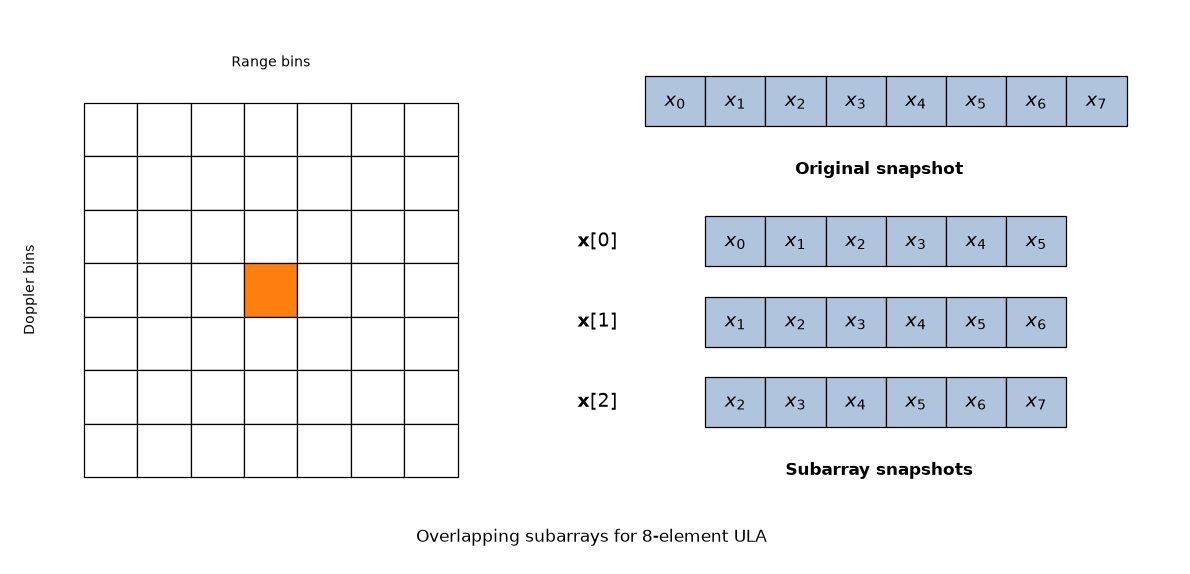

In [15]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------
def draw_rd_map(ax, x0, y0, n_rows=7, n_cols=7, sel_row=3, sel_col=3,
                cell_size=0.8, sel_color="tab:orange"):
    """Draw a simple RD map with one highlighted center cell."""
    for r in range(n_rows):
        for c in range(n_cols):
            facecolor = sel_color if (r == sel_row and c == sel_col) else "white"
            rect = Rectangle(
                (x0 + c * cell_size, y0 + r * cell_size),
                cell_size,
                cell_size,
                facecolor=facecolor,
                edgecolor="black",
                linewidth=0.9,
            )
            ax.add_patch(rect)

    # Optional axis labels
    width = n_cols * cell_size
    height = n_rows * cell_size

    ax.text(
        x0 + width / 2,
        y0 - 0.6,
        "Range bins",
        ha="center",
        va="center",
        fontsize=10,
    )
    ax.text(
        x0 - 0.8,
        y0 + height / 2,
        "Doppler bins",
        ha="center",
        va="center",
        rotation=90,
        fontsize=10,
    )


def draw_snapshot(ax, x0, y0, labels, title=None, cell_w=0.9, cell_h=0.75):
    """Draw one horizontal snapshot row."""
    n = len(labels)

    if title is not None:
        ax.text(
            x0 - 1.3,
            y0 + cell_h / 2,
            title,
            ha="right",
            va="center",
            fontsize=14,
            fontweight="bold",
        )

    for k, lbl in enumerate(labels):
        rect = Rectangle(
            (x0 + k * cell_w, y0),
            cell_w,
            cell_h,
            facecolor="lightsteelblue",
            edgecolor="black",
            linewidth=0.9,
        )
        ax.add_patch(rect)

        ax.text(
            x0 + k * cell_w + cell_w / 2,
            y0 + cell_h / 2,
            lbl,
            ha="center",
            va="center",
            fontsize=14,
        )


# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6.8))

# Left: RD map
rd_x0 = 0.6
rd_y0 = 1.6
draw_rd_map(ax, rd_x0, rd_y0, n_rows=7, n_cols=7, sel_row=3, sel_col=3, cell_size=0.8)

# Right: original snapshot + overlapping subarrays
snap_x0 = 9.0
row_gap = 1.2

orig_labels = [rf"$x_{k}$" for k in range(8)]
sub0_labels = [rf"$x_{k}$" for k in range(6)]
sub1_labels = [rf"$x_{k}$" for k in range(1, 7)]
sub2_labels = [rf"$x_{k}$" for k in range(2, 8)]

draw_snapshot(ax, snap_x0, 1.2, orig_labels, None)
draw_snapshot(ax, snap_x0 + 0.9, 2.1 + row_gap, sub0_labels, title=r"$\mathbf{x}[0]$")
draw_snapshot(ax, snap_x0 + 0.9, 2.1 + 2 * row_gap, sub1_labels, title=r"$\mathbf{x}[1]$")
draw_snapshot(ax, snap_x0 + 0.9, 2.1 + 3 * row_gap, sub2_labels, title=r"$\mathbf{x}[2]$")

# Bottom annotation
ax.text(
    8.2,
    3.0 + 4.25 * row_gap,
    "Overlapping subarrays for 8-element ULA",
    ha="center",
    va="center",
    fontsize=12,
)

ax.text(
    snap_x0 + 3.5,
    -2.5 + 4.25 * row_gap,
    "Original snapshot",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
)

ax.text(
    snap_x0 + 3.5,
    2.0 + 4.25 * row_gap,
    "Subarray snapshots",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
)

# Formatting
ax.set_xlim(-0.5, 17.0)
ax.set_ylim(0.2, 8.5)
ax.invert_yaxis()
ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout()

plt.savefig(
    "../docs/images/overlapping_subarrays.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

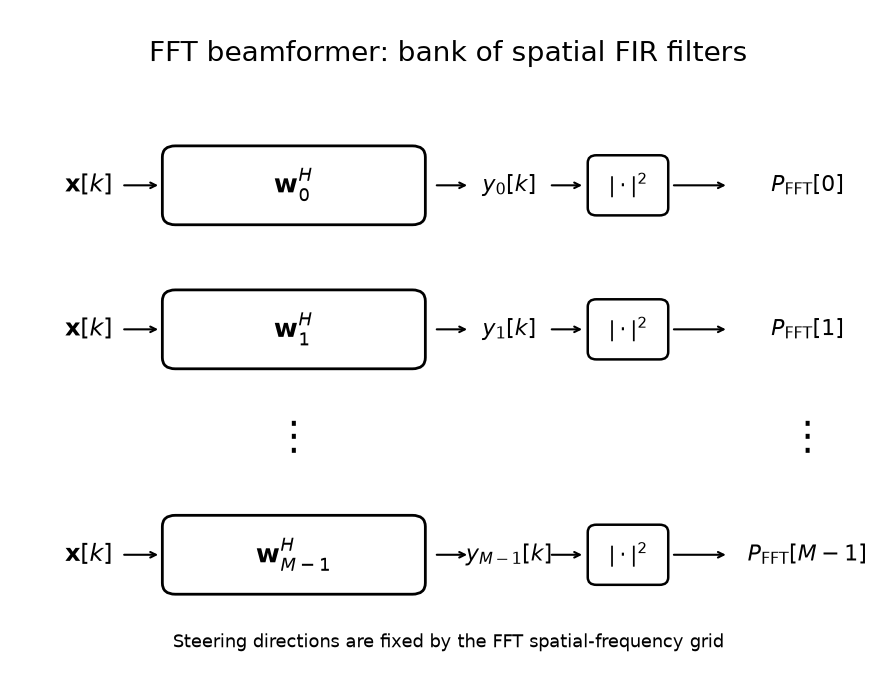

In [30]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ------------------------------------------------------------
# FFT beamformer: bank of spatial FIR filters
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 7))

# Title
ax.text(
    6.1, 11.3,
    "FFT beamformer: bank of spatial FIR filters",
    ha="center",
    va="center",
    fontsize=20,
)

# Vertical positions of displayed filters
y_positions = [9.2, 6.9, 3.3]
indices = [0, 1, "M-1"]

for y, idx in zip(y_positions, indices):

    # Input label
    ax.text(
        1.1, y,
        r"$\mathbf{x}[k]$",
        ha="center",
        va="center",
        fontsize=17,
    )

    # Input arrow
    ax.annotate(
        "",
        xy=(2.1, y),
        xytext=(1.55, y),
        arrowprops=dict(arrowstyle="->", linewidth=1.5),
    )

    # Filter block
    block1 = FancyBboxPatch(
        (2.2, y - 0.55),
        3.5,
        1.1,
        boxstyle="round,pad=0.08,rounding_size=0.18",
        fill=False,
        linewidth=2.0,
    )
    ax.add_patch(block1)

    # Filter coefficient
    ax.text(
        3.95, y,
        rf"$\mathbf{{w}}_{{{idx}}}^{{H}}$",
        ha="center",
        va="center",
        fontsize=19,
    )

    # Arrow to beamformer output
    ax.annotate(
        "",
        xy=(6.4, y),
        xytext=(5.9, y),
        arrowprops=dict(arrowstyle="->", linewidth=1.5),
    )

    # Output label
    ax.text(
        6.95, y,
        rf"$y_{{{idx}}}[k]$",
        ha="center",
        va="center",
        fontsize=16,
    )

    # Arrow to power block
    ax.annotate(
        "",
        xy=(8.0, y),
        xytext=(7.5, y),
        arrowprops=dict(arrowstyle="->", linewidth=1.5),
    )

    # Power block
    block2 = FancyBboxPatch(
        (8.1, y - 0.42),
        1.0,
        0.84,
        boxstyle="round,pad=0.06,rounding_size=0.12",
        fill=False,
        linewidth=1.8,
    )
    ax.add_patch(block2)

    ax.text(
        8.6, y,
        r"$|\cdot|^2$",
        ha="center",
        va="center",
        fontsize=15,
    )

    # Arrow to power spectrum sample
    ax.annotate(
        "",
        xy=(10.0, y),
        xytext=(9.2, y),
        arrowprops=dict(arrowstyle="->", linewidth=1.5),
    )

    ax.text(
        11.1, y,
        rf"$P_{{\mathrm{{FFT}}}}[{idx}]$",
        ha="center",
        va="center",
        fontsize=16,
    )

# Vertical ellipsis
ax.text(
    3.95, 5.15,
    r"$\vdots$",
    ha="center",
    va="center",
    fontsize=28,
)

ax.text(
    11.1, 5.15,
    r"$\vdots$",
    ha="center",
    va="center",
    fontsize=28,
)

# Small annotation
ax.text(
    6.1, 1.9,
    r"Steering directions are fixed by the FFT spatial-frequency grid",
    ha="center",
    va="center",
    fontsize=13,
)

ax.set_xlim(0, 12)
ax.set_ylim(1.3, 12)
ax.axis("off")

plt.tight_layout()
plt.savefig(
    "../docs/images/fft_bank_of_fir.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

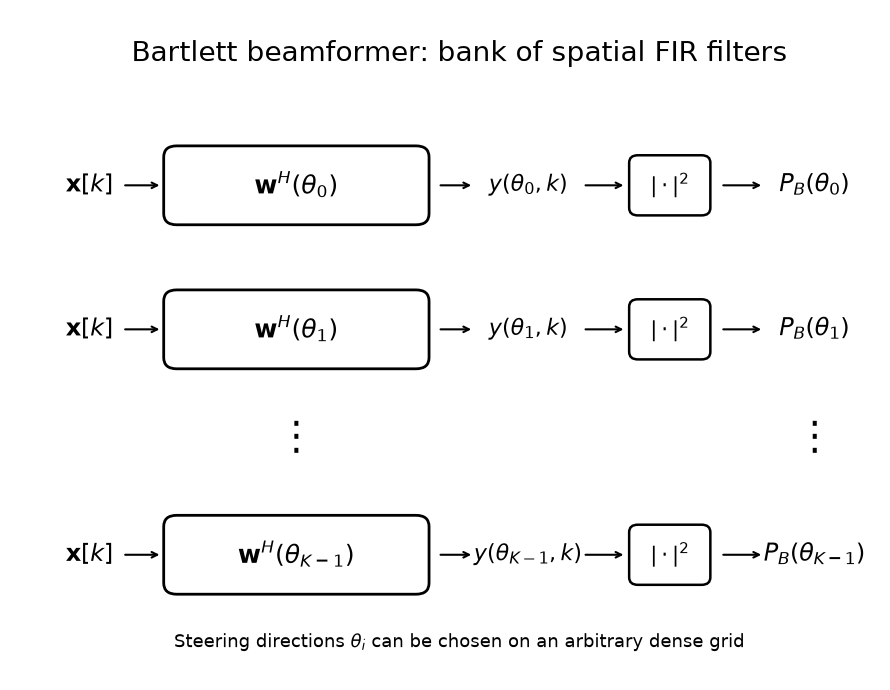

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ------------------------------------------------------------
# Bartlett beamformer on an angular steering grid
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 7))

# Title
ax.text(
    6.2, 11.3,
    "Bartlett beamformer: bank of spatial FIR filters",
    ha="center",
    va="center",
    fontsize=20,
)

# Vertical positions of displayed branches
y_positions = [9.2, 6.9, 3.3]
angle_labels = [r"\theta_0", r"\theta_1", r"\theta_{K-1}"]

for y, ang in zip(y_positions, angle_labels):

    # Input label
    ax.text(
        1.1, y,
        r"$\mathbf{x}[k]$",
        ha="center",
        va="center",
        fontsize=17,
    )

    # Input arrow
    ax.annotate(
        "",
        xy=(2.1, y),
        xytext=(1.55, y),
        arrowprops=dict(arrowstyle="->", linewidth=1.5),
    )

    # Steering / beamformer block
    block1 = FancyBboxPatch(
        (2.2, y - 0.55),
        3.5,
        1.1,
        boxstyle="round,pad=0.08,rounding_size=0.18",
        fill=False,
        linewidth=2.0,
    )
    ax.add_patch(block1)

    ax.text(
        3.95, y,
        rf"$\mathbf{{w}}^H({ang})$",
        ha="center",
        va="center",
        fontsize=18,
    )

    # Arrow to beamformer output
    ax.annotate(
        "",
        xy=(6.4, y),
        xytext=(5.9, y),
        arrowprops=dict(arrowstyle="->", linewidth=1.5),
    )

    # Output label
    ax.text(
        7.15, y,
        rf"$y({ang}, k)$",
        ha="center",
        va="center",
        fontsize=16,
    )

    # Arrow to power block
    ax.annotate(
        "",
        xy=(8.5, y),
        xytext=(7.9, y),
        arrowprops=dict(arrowstyle="->", linewidth=1.5),
    )

    # Power block
    block2 = FancyBboxPatch(
        (8.6, y - 0.42),
        1.0,
        0.84,
        boxstyle="round,pad=0.06,rounding_size=0.12",
        fill=False,
        linewidth=1.8,
    )
    ax.add_patch(block2)

    ax.text(
        9.1, y,
        r"$|\cdot|^2$",
        ha="center",
        va="center",
        fontsize=15,
    )

    # Arrow to final spectrum sample
    ax.annotate(
        "",
        xy=(10.4, y),
        xytext=(9.8, y),
        arrowprops=dict(arrowstyle="->", linewidth=1.5),
    )

    ax.text(
        11.1, y,
        rf"$P_B({ang})$",
        ha="center",
        va="center",
        fontsize=17,
    )

# Vertical ellipsis
ax.text(
    3.95, 5.15,
    r"$\vdots$",
    ha="center",
    va="center",
    fontsize=28,
)
ax.text(
    11.1, 5.15,
    r"$\vdots$",
    ha="center",
    va="center",
    fontsize=28,
)

# Small annotation
ax.text(
    6.2, 1.9,
    r"Steering directions $\theta_i$ can be chosen on an arbitrary dense grid",
    ha="center",
    va="center",
    fontsize=13,
)

ax.set_xlim(0, 12)
ax.set_ylim(1.3, 12)
ax.axis("off")

plt.tight_layout()
plt.savefig(
    "../docs/images/bartlett_steering_grid.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

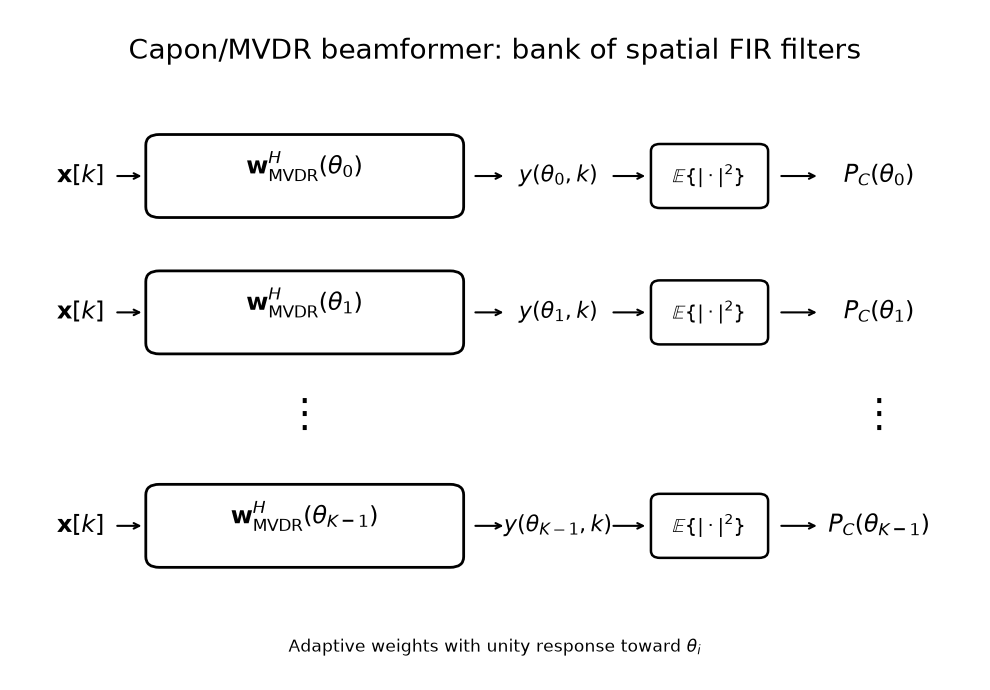

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ------------------------------------------------------------
# Capon/MVDR beamformer on an angular steering grid
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 7))

# Title
ax.text(
    6.5, 11.3,
    "Capon/MVDR beamformer: bank of spatial FIR filters",
    ha="center",
    va="center",
    fontsize=20,
)

# Vertical positions of displayed branches
y_positions = [9.2, 6.9, 3.3]
angle_labels = [r"\theta_0", r"\theta_1", r"\theta_{K-1}"]

for y, ang in zip(y_positions, angle_labels):

    # Input snapshot
    ax.text(
        0.95, y,
        r"$\mathbf{x}[k]$",
        ha="center",
        va="center",
        fontsize=17,
    )

    ax.annotate(
        "",
        xy=(1.8, y),
        xytext=(1.4, y),
        arrowprops=dict(arrowstyle="->", linewidth=1.5),
    )

    # Adaptive Capon/MVDR spatial filter
    beamformer_block = FancyBboxPatch(
        (1.9, y - 0.62),
        4.1,
        1.24,
        boxstyle="round,pad=0.08,rounding_size=0.18",
        fill=False,
        linewidth=2.0,
    )
    ax.add_patch(beamformer_block)

    ax.text(
        3.95, y + 0.16,
        rf"$\mathbf{{w}}_{{\mathrm{{MVDR}}}}^H({ang})$",
        ha="center",
        va="center",
        fontsize=17,
    )

    # Beamformer output
    ax.annotate(
        "",
        xy=(6.65, y),
        xytext=(6.2, y),
        arrowprops=dict(arrowstyle="->", linewidth=1.5),
    )

    ax.text(
        7.35, y,
        rf"$y({ang},k)$",
        ha="center",
        va="center",
        fontsize=16,
    )

    # Arrow to output-power estimate
    ax.annotate(
        "",
        xy=(8.55, y),
        xytext=(8.05, y),
        arrowprops=dict(arrowstyle="->", linewidth=1.5),
    )

    power_block = FancyBboxPatch(
        (8.65, y - 0.48),
        1.45,
        0.96,
        boxstyle="round,pad=0.06,rounding_size=0.12",
        fill=False,
        linewidth=1.8,
    )
    ax.add_patch(power_block)

    ax.text(
        9.375, y,
        r"$\mathbb{E}\{|\cdot|^2\}$",
        ha="center",
        va="center",
        fontsize=14,
    )

    # Capon spectrum sample
    ax.annotate(
        "",
        xy=(10.85, y),
        xytext=(10.3, y),
        arrowprops=dict(arrowstyle="->", linewidth=1.5),
    )

    ax.text(
        11.65, y,
        rf"$P_C({ang})$",
        ha="center",
        va="center",
        fontsize=17,
    )

# Vertical ellipses
ax.text(
    3.95, 5.15,
    r"$\vdots$",
    ha="center",
    va="center",
    fontsize=28,
)

ax.text(
    11.65, 5.15,
    r"$\vdots$",
    ha="center",
    va="center",
    fontsize=28,
)


# Explanation
ax.text(
    6.5, 1.25,
    r"Adaptive weights with unity response toward $\theta_i$",
    ha="center",
    va="center",
    fontsize=12.5,
)

ax.set_xlim(0, 13)
ax.set_ylim(0.7, 12)
ax.axis("off")

plt.tight_layout()

plt.savefig(
    "../docs/images/capon_mvdr_steering_grid.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

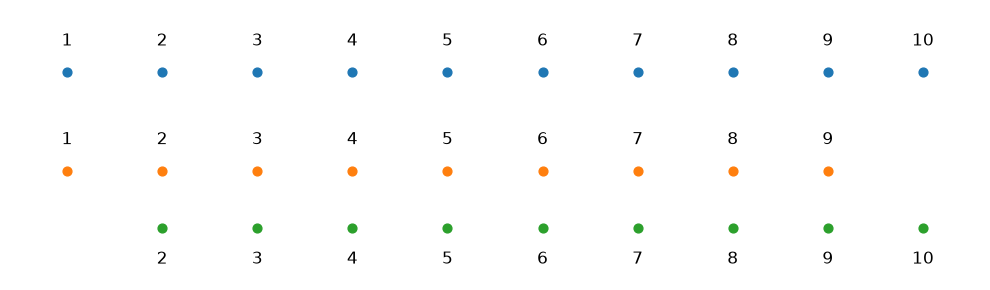

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# ESPRIT shift-invariant subarrays
# ------------------------------------------------------------

M = 10
x = np.arange(1, M + 1)

fig, ax = plt.subplots(figsize=(10, 3))

# Full array
y_full = 2.0
ax.scatter(x, np.full(M, y_full), s=40)

for i in x:
    ax.text(i, y_full + 0.22, str(i),
            ha="center", va="bottom", fontsize=12)

# Subarray 1: elements 1 ... M-1
y_sub1 = 1.05
ax.scatter(x[:-1], np.full(M - 1, y_sub1), s=40)

for i in x[:-1]:
    ax.text(i, y_sub1 + 0.22, str(i),
            ha="center", va="bottom", fontsize=12)

# Subarray 2: elements 2 ... M
y_sub2 = 0.50
ax.scatter(x[1:], np.full(M - 1, y_sub2), s=40)

for i in x[1:]:
    ax.text(i, y_sub2 - 0.22, str(i),
            ha="center", va="top", fontsize=12)

ax.set_xlim(0.4, M + 0.6)
ax.set_ylim(0.0, 2.6)
ax.axis("off")

plt.tight_layout()
plt.savefig(
    "../docs/images/esprit_shift_invariance.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()